# 연습문제

privacy 데이터셋은 제주도 남녀 대학생의 개인정보 관리방법에 관한 설문조사 결과이다.
자료를 직접 입력하고 남녀별 메모의 종류별로 비율을 확인 할 수 있는 데이터를 구성하고 시각화하라

In [10]:
from hossam import load_data
from pandas import crosstab
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb

In [2]:
origin = load_data("privacy")
origin

[data] https://data.hossam.kr/data/lab09/privacy.xlsx
[desc] 제주도 남녀 대학생의 개인정보 관리방법에 관한 설문조사 결과 데이터 (출처: 사회조사분석사 2급 실기작업형 기출)
[!] Cannot read metadata


,학생ID,성별,메모종류
0,1,남,3
1,2,여,2
2,3,여,2
3,4,여,1
4,5,여,2
5,6,여,3
6,7,남,2
7,8,여,2
8,9,여,1
9,10,남,1


In [3]:
my_dpi = 200
fpath = "./NotoSansKR-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트의 이름만 추출
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False

In [4]:
origin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   학생ID    30 non-null     int64 
 1   성별      30 non-null     object
 2   메모종류    30 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 852.0+ bytes


In [5]:
df = origin.astype({'성별': 'category', '메모종류': 'category'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   학생ID    30 non-null     int64   
 1   성별      30 non-null     category
 2   메모종류    30 non-null     category
dtypes: category(2), int64(1)
memory usage: 688.0 bytes


In [6]:
df.describe(include='category')

,성별,메모종류
count,30,30
unique,2,3
top,여,2
freq,22,20


In [13]:
cb1 = crosstab(index=df['성별'], columns=df['메모종류'],normalize=True)
cb1

메모종류,1,2,3
성별,,,
남,0.066667,0.133333,0.066667
여,0.133333,0.533333,0.066667


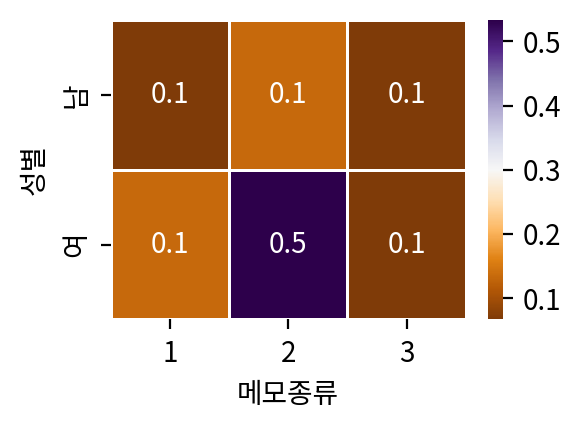

In [15]:
# 1) 그래프 초기화
width_px = 600 # 그래프 가로 크기
height_px = 450 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 1 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) heatmap 그리기
sb.heatmap(data=cb1, annot=True, fmt="0.1f", linewidth=0.5, cmap="PuOr")
# 3) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료